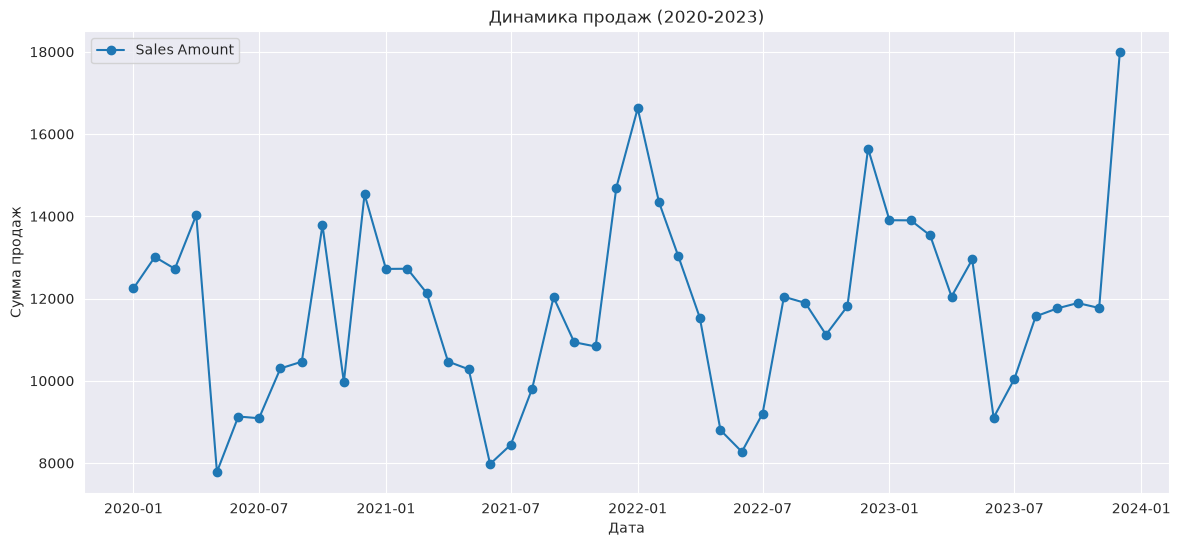

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from scipy.fft import fft, fftfreq
import pywt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error, r2_score
from statsmodels.stats.diagnostic import acorr_ljungbox, het_breuschpagan
from statsmodels.stats.stattools import jarque_bera
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from scipy import stats


df = pd.read_csv('./data/sales.csv')
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)
df = df.asfreq('MS')

plt.figure(figsize=(14, 6))
plt.plot(df.index, df['SalesAmount'], marker='o', label='Sales Amount')
plt.title('Динамика продаж (2020-2023)')
plt.xlabel('Дата')
plt.ylabel('Сумма продаж')
plt.grid(True)
plt.legend()
plt.show()


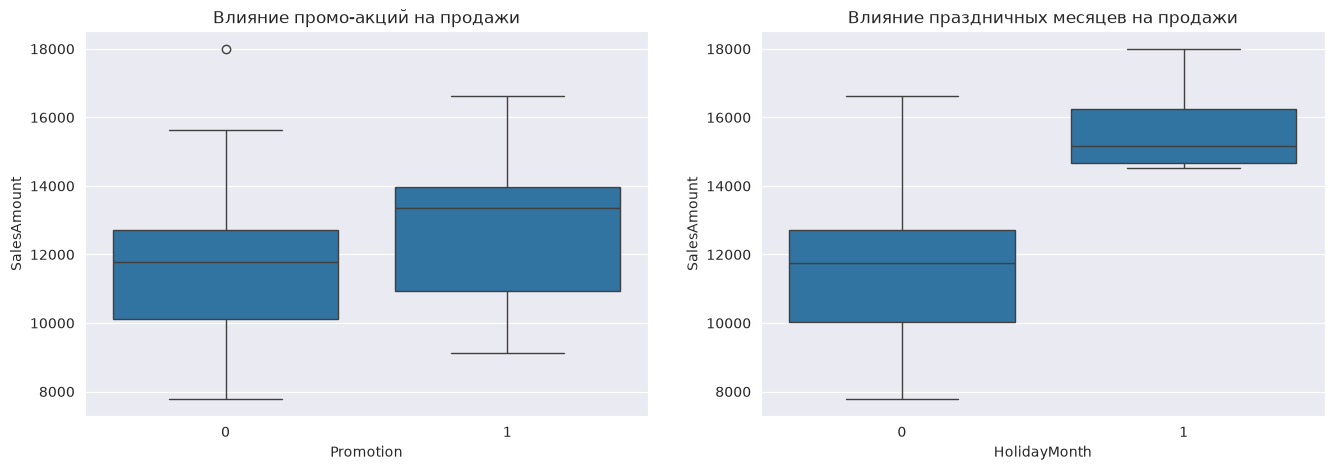

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.boxplot(x='Promotion', y='SalesAmount', data=df, ax=axes[0])
axes[0].set_title('Влияние промо-акций на продажи')
sns.boxplot(x='HolidayMonth', y='SalesAmount', data=df, ax=axes[1])
axes[1].set_title('Влияние праздничных месяцев на продажи')
plt.show()

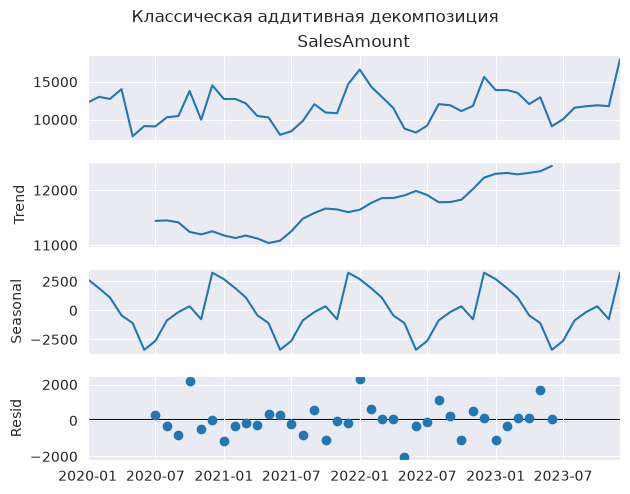

In [6]:
# Классическая аддитивная декомпозиция (период = 12)
decomp_classic = seasonal_decompose(df['SalesAmount'], model='additive', period=12)
decomp_classic.plot()
plt.suptitle('Классическая аддитивная декомпозиция', y=1.02)
plt.show()

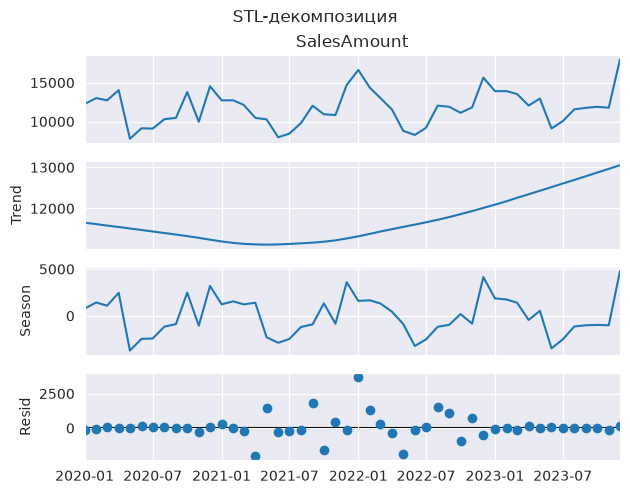

In [7]:
# STL-декомпозиция (более устойчива к выбросам)
stl = STL(df['SalesAmount'], period=12, robust=True)
res = stl.fit()
res.plot()
plt.suptitle('STL-декомпозиция', y=1.02)
plt.show()

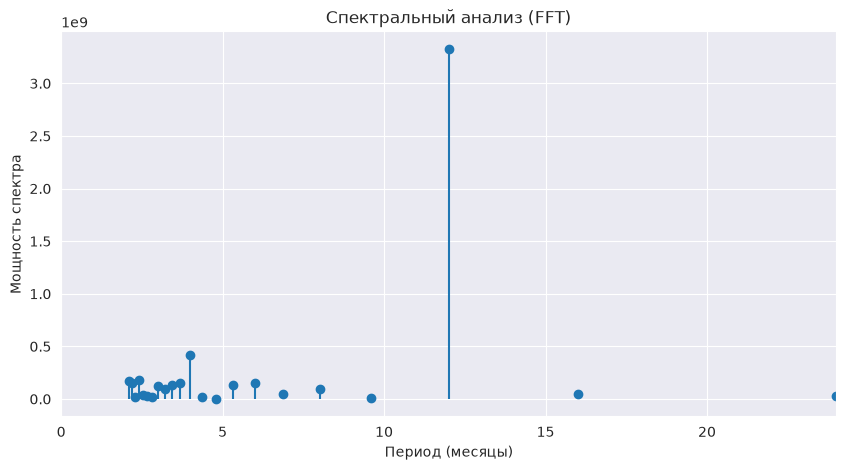

In [8]:
# Быстрое преобразование Фурье
y = df['SalesAmount'].values
y = y - np.mean(y) # Убираем константу (тренд)

N = len(y)
yf = fft(y)
xf = fftfreq(N, 1) # Частота (1/месяц)

# Только положительные частоты
idx = np.where(xf > 0)
freqs = xf[idx]
power = np.abs(yf[idx])**2

# Перевод частоты в периоды (месяцы)
periods = 1 / freqs

plt.figure(figsize=(10, 5))
plt.stem(periods, power, basefmt=" ")
plt.xlabel('Период (месяцы)')
plt.ylabel('Мощность спектра')
plt.title('Спектральный анализ (FFT)')
plt.xlim(0, 24)
plt.grid(True)
plt.show()

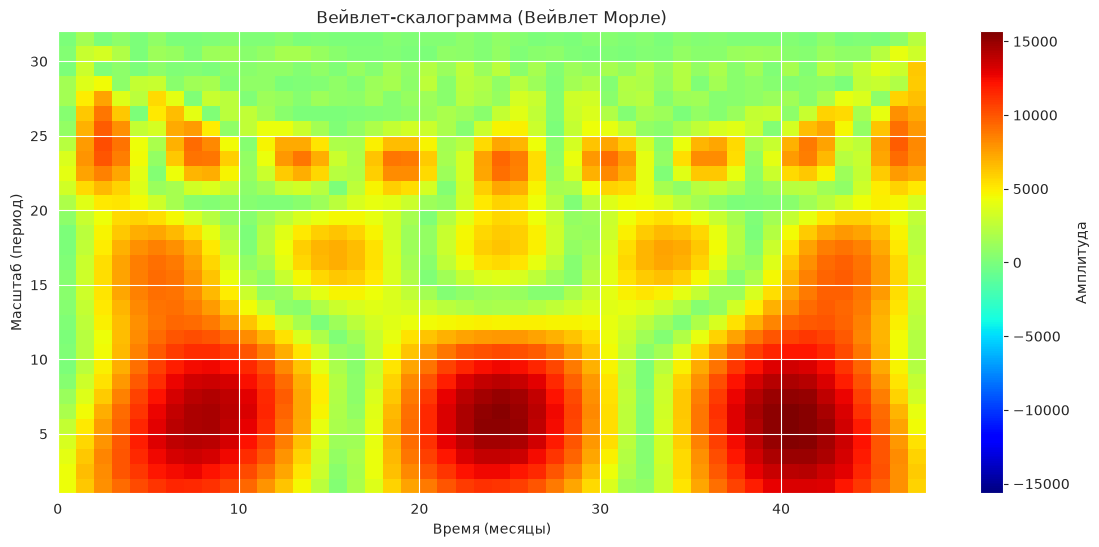

In [9]:
# Непрерывное вейвлет-преобразование (CWT) с вейвлетом Морле
scales = np.arange(1, 32)
coefficients, frequencies = pywt.cwt(df['SalesAmount'], scales, 'morl')

plt.figure(figsize=(14, 6))
plt.imshow(np.abs(coefficients), extent=[0, len(df), 1, 32], cmap='jet', aspect='auto', vmax=abs(coefficients).max(), vmin=-abs(coefficients).max())
plt.colorbar(label='Амплитуда')
plt.title('Вейвлет-скалограмма (Вейвлет Морле)')
plt.xlabel('Время (месяцы)')
plt.ylabel('Масштаб (период)')
plt.show()

In [12]:
train = df.iloc[:-12]
test = df.iloc[-12:]

print(f"Train: {train.index.min()} - {train.index.max()} ({len(train)} мес.)")
print(f"Test:  {test.index.min()} - {test.index.max()} ({len(test)} мес.)")

Train: 2020-01-01 00:00:00 - 2022-12-01 00:00:00 (36 мес.)
Test:  2023-01-01 00:00:00 - 2023-12-01 00:00:00 (12 мес.)


In [19]:
model_arima = ARIMA(train['SalesAmount'], order=(1, 1, 1))
results_arima = model_arima.fit()

# Прогноз на 12 месяцев
forecast_arima = results_arima.forecast(steps=len(test))

# Экзогенные переменные: Promotion, HolidayMonth
exog_train = train[['Promotion', 'HolidayMonth']]
exog_test = test[['Promotion', 'HolidayMonth']]

# SARIMAX: (p,d,q)=(0,1,1), (P,D,Q,s)=(1,1,0,12)
model_sarimax = SARIMAX(
    train['SalesAmount'],
    exog=exog_train,
    order=(0, 1, 1),
    seasonal_order=(1, 1, 0, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)
results_sarimax = model_sarimax.fit(disp=False, maxiter=500)

# Прогноз на 12 месяцев с учетом известных экзогенных переменных на тесте
forecast_sarimax = results_sarimax.forecast(steps=len(test), exog=exog_test)

##################################################################
##################################################################

# Расчет метрик
def evaluate_model(actual, predicted, name):
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    print(f"--- {name} ---")
    print(f"MAE:  {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAPE: {mape:.2f}%\n")

evaluate_model(test['SalesAmount'], forecast_arima,   "ARIMA(1,1,1)")
evaluate_model(test['SalesAmount'], forecast_sarimax, "SARIMAX(0,1,1)(1,1,0,12)")

--- ARIMA(1,1,1) ---
MAE:  3253.86
RMSE: 3544.32
MAPE: 28.28%

--- SARIMAX(0,1,1)(1,1,0,12) ---
MAE:  551.99
RMSE: 737.27
MAPE: 4.18%



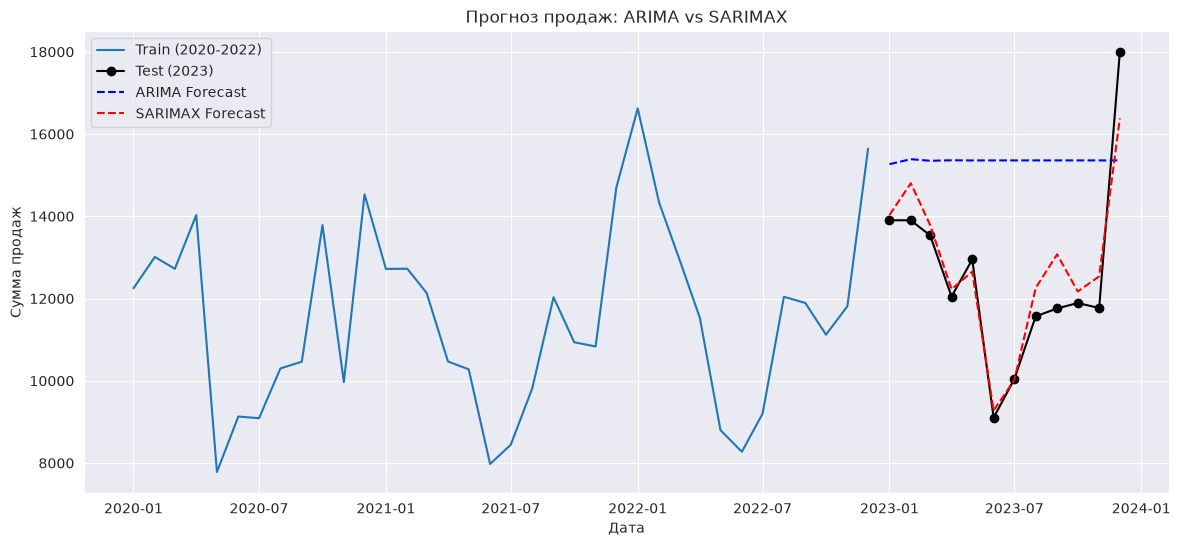

In [20]:
# Визуализация
plt.figure(figsize=(14, 6))
plt.plot(train.index, train['SalesAmount'], label='Train (2020-2022)')
plt.plot(test.index, test['SalesAmount'], label='Test (2023)', color='black', marker='o')
plt.plot(test.index, forecast_arima, label='ARIMA Forecast', color='blue', linestyle='--')
plt.plot(test.index, forecast_sarimax, label='SARIMAX Forecast', color='red', linestyle='--')
plt.title('Прогноз продаж: ARIMA vs SARIMAX')
plt.xlabel('Дата')
plt.ylabel('Сумма продаж')
plt.legend()
plt.grid(True)
plt.show()

In [24]:
mse_arima = mean_squared_error(test['SalesAmount'], forecast_arima)
r2_arima  = r2_score(test['SalesAmount'], forecast_arima)

mse_sarimax = mean_squared_error(test['SalesAmount'], forecast_sarimax)
r2_sarimax  = r2_score(test['SalesAmount'], forecast_sarimax)

metrics_df = pd.DataFrame({
    'Модель': ['ARIMA(1,1,1)', 'SARIMAX(1,1,1)(1,1,1,12)'],
    'MSE':    [mse_arima, mse_sarimax],
    'R²':     [r2_arima, r2_sarimax],
    'AIC':    [results_arima.aic, results_sarimax.aic],
    'BIC':    [results_arima.bic, results_sarimax.bic],
})

print("\n============ Таблица метрик ============")
print(metrics_df.round(2).to_string(index=False))


============ Таблица метрик ============
                  Модель         MSE    R²    AIC    BIC
            ARIMA(1,1,1) 12562213.43 -1.72 643.80 648.47
SARIMAX(1,1,1)(1,1,1,12)   543571.62  0.88 179.87 181.86



--- Анализ остатков: ARIMA(1,1,1) ---
Наблюдений: всего=36, после удаления NaN=36
Jarque-Bera p-value: 0.0000 -> нормальность НАРУШЕНА
Ljung-Box (lag=12) p-value: 0.7067 -> OK
Breusch-Pagan: пропущен (нет экзогенных переменных)

--- Анализ остатков: SARIMAX(0,1,1)(1,1,0,12) ---
Наблюдений: всего=36, после удаления NaN=36
Jarque-Bera p-value: 0.0000 -> нормальность НАРУШЕНА
Ljung-Box (lag=12) p-value: 0.5797 -> OK
Breusch-Pagan p-value: 0.9052 -> OK
Сохранено: diagnostics_arima.png


/tmp/ipykernel_68928/560427362.py:65: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


Сохранено: diagnostics_sarimax.png


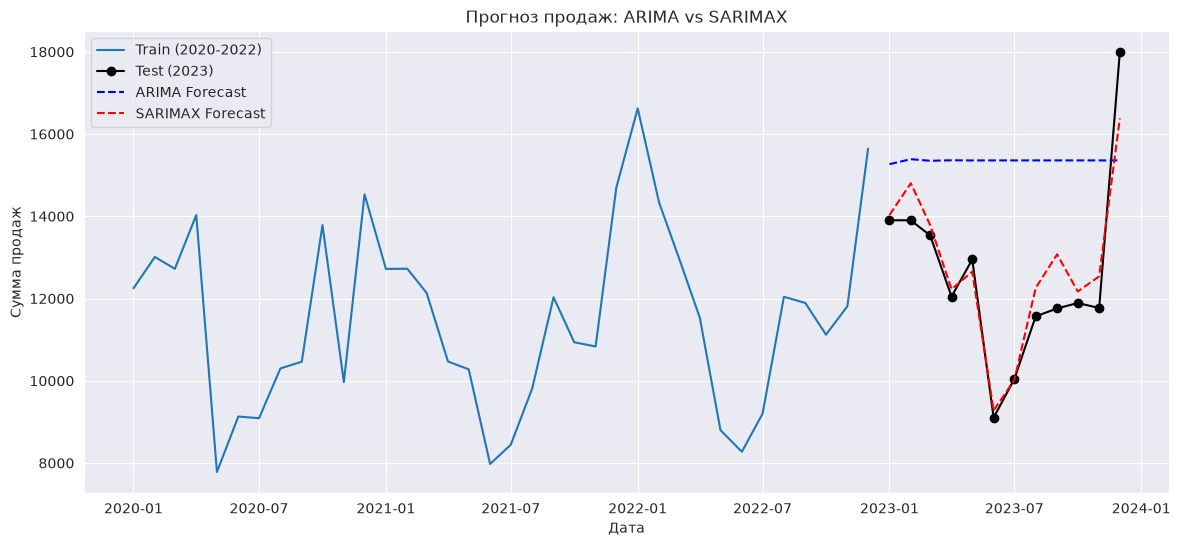

In [32]:
# --- Анализ остатков (числа) ---
def analyze_residuals(results, model_name, exog=None):
    print(f"\n--- Анализ остатков: {model_name} ---")

    resid = np.asarray(results.resid).flatten()
    resid_clean = resid[~np.isnan(resid)]
    print(f"Наблюдений: всего={len(resid)}, после удаления NaN={len(resid_clean)}")

    _, jb_pvalue, _, _ = jarque_bera(resid_clean)
    verdict_norm = "OK" if jb_pvalue > 0.05 else "НАРУШЕНА"
    print(f"Jarque-Bera p-value: {jb_pvalue:.4f} -> нормальность {verdict_norm}")

    lb = acorr_ljungbox(resid_clean, lags=[12], return_df=True)
    lb_pvalue = lb['lb_pvalue'].values[0]
    verdict_ac = "OK" if lb_pvalue > 0.05 else "ЕСТЬ АВТОКОРРЕЛЯЦИЯ"
    print(f"Ljung-Box (lag=12) p-value: {lb_pvalue:.4f} -> {verdict_ac}")

    if exog is not None:
        exog_arr = np.asarray(exog)
        if exog_arr.ndim == 1:
            exog_arr = exog_arr.reshape(-1, 1)

        n_diff = len(exog_arr) - len(resid_clean)
        exog_aligned = exog_arr[n_diff:] if n_diff > 0 else exog_arr
        exog_bp = sm.add_constant(exog_aligned, has_constant='add')

        try:
            _, bp_pvalue, _, _ = het_breuschpagan(resid_clean, exog_bp)
            verdict_hs = "OK" if bp_pvalue > 0.05 else "ГЕТЕРОСКЕДАСТИЧНОСТЬ"
            print(f"Breusch-Pagan p-value: {bp_pvalue:.4f} -> {verdict_hs}")
        except Exception as e:
            print(f"Breusch-Pagan: не удалось выполнить ({e})")
    else:
        print("Breusch-Pagan: пропущен (нет экзогенных переменных)")


# ARIMA — без экзогенных переменных
analyze_residuals(results_arima, "ARIMA(1,1,1)", exog=None)
# SARIMAX — имя исправлено под фактический порядок
analyze_residuals(results_sarimax, "SARIMAX(0,1,1)(1,1,0,12)", exog=exog_train)


# --- Графическая диагностика (ручная, устойчивая к короткому ряду) ---
def plot_residuals_manual(results, name):
    resid = np.asarray(results.resid).flatten()
    resid = resid[~np.isnan(resid)]

    fig, axes = plt.subplots(2, 2, figsize=(14, 8))

    axes[0, 0].plot(resid)
    axes[0, 0].axhline(0, color='red', linestyle='--')
    axes[0, 0].set_title('Остатки во времени')

    axes[0, 1].hist(resid, bins=15, edgecolor='black')
    axes[0, 1].set_title('Распределение остатков')

    plot_acf(resid, lags=min(10, len(resid)//2 - 1), ax=axes[1, 0])
    axes[1, 0].set_title('ACF остатков')

    stats.probplot(resid, dist="norm", plot=axes[1, 1])
    axes[1, 1].set_title('QQ-plot')

    fig.suptitle(f'Диагностика остатков: {name}', y=1.02)
    fig.tight_layout()
    fig.show()
    plt.close(fig)
    print(f"Сохранено: diagnostics_{name.lower()}.png")

plot_residuals_manual(results_arima, 'ARIMA')
plot_residuals_manual(results_sarimax, 'SARIMAX')


# --- Итоговый график прогноза ---
plt.figure(figsize=(14, 6))
plt.plot(train.index, train['SalesAmount'], label='Train (2020-2022)')
plt.plot(test.index, test['SalesAmount'], label='Test (2023)', color='black', marker='o')
plt.plot(test.index, forecast_arima, label='ARIMA Forecast', color='blue', linestyle='--')
plt.plot(test.index, forecast_sarimax, label='SARIMAX Forecast', color='red', linestyle='--')
plt.title('Прогноз продаж: ARIMA vs SARIMAX')
plt.xlabel('Дата')
plt.ylabel('Сумма продаж')
plt.legend()
plt.grid(True)
plt.show()
plt.close()
